In [26]:
import math
import time
import numpy as np
import pandas as pd
import datetime as dt
from pylab import plt, mpl

In [27]:
import tpqoa
%time api = tpqoa.tpqoa('/workspace/src/pyalgo_netting.cfg')

CPU times: user 997 μs, sys: 201 μs, total: 1.2 ms
Wall time: 861 μs


In [28]:
instrument = 'EUR_USD'

In [29]:
raw = api.get_history(instrument,
                      start='2020-06-08',
                      end='2020-06-13',
                      granularity='M10',
                      price='M')

In [30]:
spread = 0.00012
mean = raw['c'].mean()
ptc = spread /mean
ptc

np.float64(0.00010599557439495706)

<Axes: xlabel='time'>

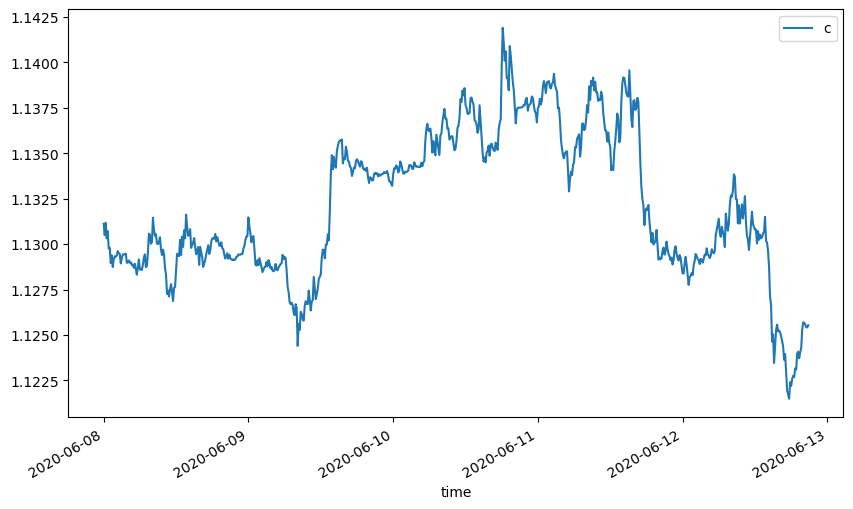

In [31]:
raw['c'].plot(figsize=(10,6),legend=True)

In [32]:
data = pd.DataFrame(raw['c'])
data.columns = [instrument,]
window = 20
data['return'] = np.log(data / data.shift(1))

In [33]:

data['vol'] = data['return'].rolling(window).std()
data['mom'] = np.sign(data['return'].rolling(window).mean())
data['sma'] = data[instrument].rolling(window).mean()
data['min'] = data[instrument].rolling(window).min()
data['max'] = data[instrument].rolling(window).max()


In [34]:

# data.dropna(inplace=True)

In [52]:
lags = 6
features = ['return', 'vol', 'mom', 'sma', 'min', 'max']
cols = []
for f in features:
    for lag in range(1, lags + 1):
        col = f'{f}_lag_{lag}'
        data[col] = data[f].shift(lag)
        cols.append(col)
data.dropna(inplace=True)

In [53]:
data['direction'] = np.where(data['return'] > 0, 1, -1)
data[cols].iloc[:lags, ]

,return_lag_1,return_lag_2,return_lag_3,return_lag_4,return_lag_5,return_lag_6,vol_lag_1,vol_lag_2,vol_lag_3,vol_lag_4,...,min_lag_3,min_lag_4,min_lag_5,min_lag_6,max_lag_1,max_lag_2,max_lag_3,max_lag_4,max_lag_5,max_lag_6
time,,,,,,,,,,,,,,,,,,,,,
2020-06-08 05:20:00,0.000195,-0.000159,0.000035,-0.000142,0.000027,-0.000115,0.000189,0.000187,0.000203,0.000240,...,1.12884,1.12874,1.12874,1.12874,1.12962,1.12962,1.12962,1.12962,1.12962,1.12962
2020-06-08 05:30:00,-0.000283,0.000195,-0.000159,0.000035,-0.000142,0.000027,0.000198,0.000189,0.000187,0.000203,...,1.12870,1.12884,1.12874,1.12874,1.12962,1.12962,1.12962,1.12962,1.12962,1.12962
2020-06-08 05:40:00,-0.000248,-0.000283,0.000195,-0.000159,0.000035,-0.000142,0.000203,0.000198,0.000189,0.000187,...,1.12870,1.12870,1.12884,1.12874,1.12962,1.12962,1.12962,1.12962,1.12962,1.12962
2020-06-08 05:50:00,0.000354,-0.000248,-0.000283,0.000195,-0.000159,0.000035,0.000214,0.000203,0.000198,0.000189,...,1.12860,1.12870,1.12870,1.12884,1.12950,1.12962,1.12962,1.12962,1.12962,1.12962
2020-06-08 06:00:00,0.000390,0.000354,-0.000248,-0.000283,0.000195,-0.000159,0.000234,0.000214,0.000203,0.000198,...,1.12832,1.12860,1.12870,1.12870,1.12948,1.12950,1.12962,1.12962,1.12962,1.12962
2020-06-08 06:10:00,-0.000496,0.000390,0.000354,-0.000248,-0.000283,0.000195,0.000257,0.000234,0.000214,0.000203,...,1.12832,1.12832,1.12860,1.12870,1.12948,1.12948,1.12950,1.12962,1.12962,1.12962


In [54]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

In [55]:
n_estimators = 15
random_state = 100
max_depth = 2
min_samples_leaf = 15
# subsample = 0.33

In [56]:
dtc = DecisionTreeClassifier(random_state=random_state,
                             max_depth=max_depth,
                             min_samples_leaf=min_samples_leaf)
model = AdaBoostClassifier(estimator=dtc,
                           n_estimators=n_estimators,
                           random_state=random_state)
split = int(len(data) * 0.7)
train = data.iloc[:split].copy()
mu, std = train.mean(), train.std()
train_ = (train - mu) / std
# mu, std = train[cols].mean(), train[cols].std()
# train_ = train.copy()
# train_[cols] = (train[cols] - mu) / std


In [57]:
print("TEXT split index:", data.index[split])

TEXT split index: 2020-06-11 11:30:00


In [58]:
model.fit(train_[cols], train['direction'])

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...dom_state=100)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",15
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [61]:

print("=== Jupyter X_train index ===")
print(list(train_[cols].index))

print("=== Jupyter columns ===")
print(list(train_[cols].columns))

print("=== Jupyter X_train head ===")
print(train_[cols].head())
print(train_[cols].tail())

print("=== Jupyter y_train ===")
print(list(train['direction']))





=== Jupyter X_train index ===
[Timestamp('2020-06-08 05:20:00'), Timestamp('2020-06-08 05:30:00'), Timestamp('2020-06-08 05:40:00'), Timestamp('2020-06-08 05:50:00'), Timestamp('2020-06-08 06:00:00'), Timestamp('2020-06-08 06:10:00'), Timestamp('2020-06-08 06:20:00'), Timestamp('2020-06-08 06:30:00'), Timestamp('2020-06-08 06:40:00'), Timestamp('2020-06-08 06:50:00'), Timestamp('2020-06-08 07:00:00'), Timestamp('2020-06-08 07:10:00'), Timestamp('2020-06-08 07:20:00'), Timestamp('2020-06-08 07:30:00'), Timestamp('2020-06-08 07:40:00'), Timestamp('2020-06-08 07:50:00'), Timestamp('2020-06-08 08:00:00'), Timestamp('2020-06-08 08:10:00'), Timestamp('2020-06-08 08:20:00'), Timestamp('2020-06-08 08:30:00'), Timestamp('2020-06-08 08:40:00'), Timestamp('2020-06-08 08:50:00'), Timestamp('2020-06-08 09:00:00'), Timestamp('2020-06-08 09:10:00'), Timestamp('2020-06-08 09:20:00'), Timestamp('2020-06-08 09:30:00'), Timestamp('2020-06-08 09:40:00'), Timestamp('2020-06-08 09:50:00'), Timestamp('2020-0

In [62]:
accuracy_score(train['direction'], model.predict(train_[cols]))

0.7286324786324786

In [63]:
test = data.iloc[split:].copy()
test_ = (test - mu) / std
test['position'] = model.predict(test_[cols])
accuracy_score(test['direction'], test['position'])

0.5870646766169154

In [64]:
print(test_[cols], test['direction'])


                     return_lag_1  return_lag_2  return_lag_3  return_lag_4  \
time                                                                          
2020-06-11 11:30:00     -0.086582     -0.856238     -1.046804     -1.691421   
2020-06-11 11:40:00     -1.136195     -0.087674     -0.859565     -1.052760   
2020-06-11 11:50:00      0.906809     -1.137955     -0.090103     -0.864972   
2020-06-11 12:00:00     -1.080036      0.906349     -1.141611     -0.093254   
2020-06-11 12:10:00     -0.480385     -1.081760      0.905082     -1.147844   
...                           ...           ...           ...           ...   
2020-06-12 20:10:00      0.707374      1.919446      0.383622      0.610365   
2020-06-12 20:20:00     -0.068196      0.706788      1.919362      0.381858   
2020-06-12 20:30:00     -0.219513     -0.069276      0.705288      1.922099   
2020-06-12 20:40:00     -0.314117     -0.220690     -0.071683      0.704467   
2020-06-12 20:50:00     -0.049287     -0.315353     

In [65]:
test['strategy'] = test['position'] * test ['return']
sum(test['position'].diff() != 0)

54

In [66]:
test['strategy_tc'] = np.where(test['position'].diff().fillna(0) != 0,
                               test['strategy'] - ptc,
                               test['strategy'])
# test['strategy_tc'] = np.where(test['position'].diff() != 0,
#                                test['strategy'] - ptc,
#                                test['strategy'])
test[['return', 'strategy', 'strategy_tc']].sum().apply(np.exp)

return         0.990592
strategy       1.016910
strategy_tc    1.011213
dtype: float64

<Axes: xlabel='time'>

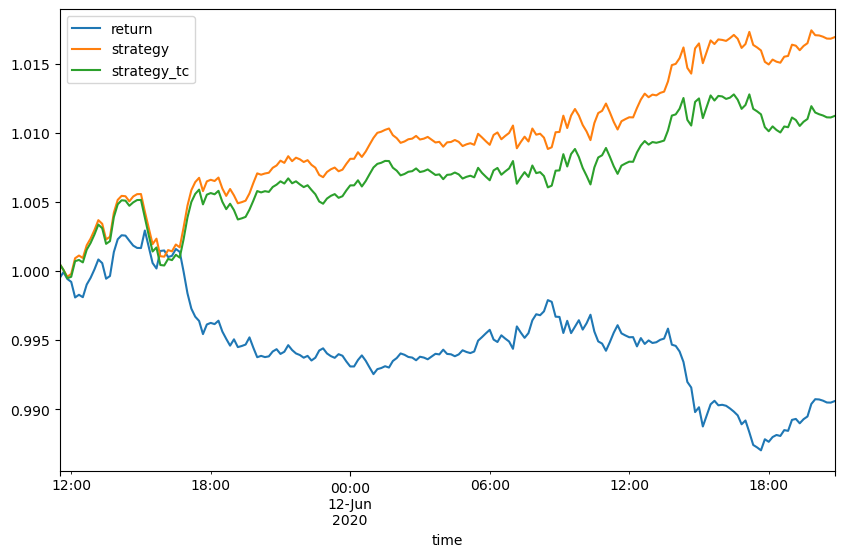

In [67]:
test[['return', 'strategy', 'strategy_tc']].cumsum().apply(np.exp).plot(figsize=(10,6))

<Axes: xlabel='time'>

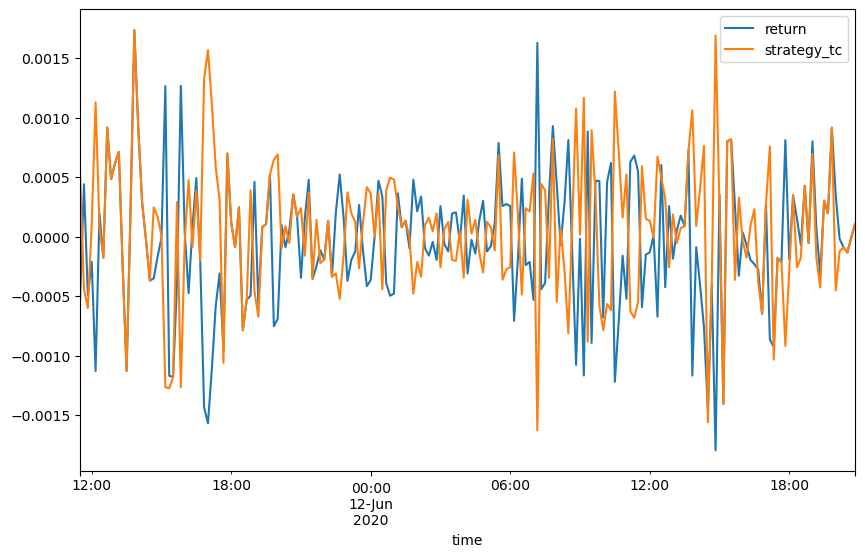

In [72]:
test[['return', 'strategy_tc']].plot(figsize=(10,6))